### Local explainability with SHAP

### Global Vs. Local explainability
| Global explainability | Local explainability|
| ----------------| -------------|
| Overall model behavior | EXplains prediction for specific data point|
|Doesn't explain individual instances | Crucial for sensitive applications |

In [1]:
import pandas as pd
heart = pd.read_csv("heart.csv")
heart.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [3]:
X = heart.drop(columns=["target"], axis=0)
y = heart['target']

X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 104.2 KB


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)


KNeighborsClassifier()

In [7]:
### Local explainability with SHAP
import shap
explainer = shap.KernelExplainer(knn.predict_proba, shap.kmeans(X, 10))

test_instance = X.iloc[0, :]

shap_values = explainer.shap_values(test_instance)

print(shap_values.shape)

(13, 2)


### SHAP waterfall plots
- Shows how features increase or decrease model's prediction

Creating waterfall plots

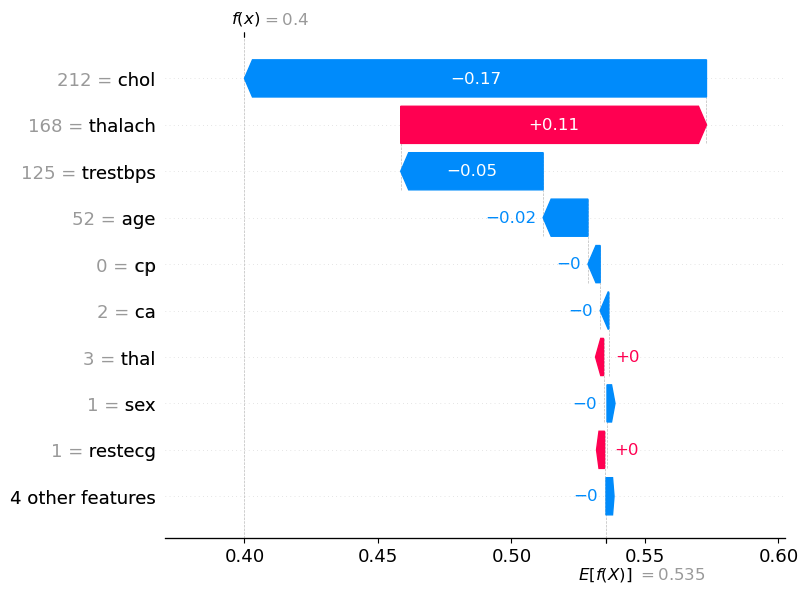

In [8]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[:,1],
        base_values=explainer.expected_value[1],
        data=test_instance,
        feature_names=X.columns

    )
)

In [ ]:
import shap

# Create the SHAP explainer
explainer = shap.KernelExplainer(model.predict_proba, shap.kmeans(X, 10))

# Compute SHAP values for the first instance in X
shap_values =explainer.shap_values( X.iloc[0, :])

print(shap_values)